In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Comparison of baselines

In [2]:
def plot_scheduler_radar(data, title="Radar Plot"):
    """
    Generate a radar chart for scheduling algorithms from a complex results dict.
    Includes Carbon Emissions as a factor, and flips 'lower-is-better' metrics so
    that higher is always better (outward = better performance).

    Parameters
    ----------
    data : dict
        Dictionary in the form:
        {
            "Algo Name": {
                "Avg Wait": value,
                "Max Wait": value,
                "Avg Response": value,
                "Avg Slowdown": value,
                "System Utilization": value,
                "Carbon Emissions": value,
                ...
            },
            ...
        }
    title : str
        Title for the radar chart.
    """

    # Metrics to plot
    metrics = ["Avg Wait", "Max Wait", "Avg Response", 
               "Avg Slowdown", "System Utilization", "Carbon Emissions"]
    num_vars = len(metrics)

    # Define which metrics should be inverted (lower is better → higher is better)
    invert_metrics = {"Avg Wait", "Max Wait", "Avg Response", 
                      "Avg Slowdown", "Carbon Emissions"}

    # Collect raw values
    all_values = {m: [float(algo[m]) for algo in data.values()] for m in metrics}
    mins = {m: min(v) for m,v in all_values.items()}
    maxs = {m: max(v) for m,v in all_values.items()}

    # Angles for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    for algo, values in data.items():
        stats = []
        for m in metrics:
            raw_val = float(values[m])

            # normalize to [0,1]
            if maxs[m] > mins[m]:
                norm_val = (raw_val - mins[m]) / (maxs[m] - mins[m])
            else:
                norm_val = 0.5  # if identical across algos

            # invert if lower is better
            if m in invert_metrics:
                norm_val = 1 - norm_val

            stats.append(norm_val)

        stats += stats[:1]  # close loop
        ax.plot(angles, stats, label=algo)
        ax.fill(angles, stats, alpha=0.1)

    # Set axis labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=10)

    plt.title(title, size=14, y=1.1)
    plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.show()


In [3]:
data = {'10-percentile Baseline': {'Avg Wait': np.float64(122535.884585211), 'Max Wait': np.float64(122535.884585211), 'Avg Response': np.float64(125674.48751163088), 'Avg Slowdown': np.float64(14798.97326313907), 'Carbon Emissions': np.float64(39400634.574480005), 'Weighted Carbon Emissions': np.float64(-39400634.574480005), 'System Utilization': np.float64(0.3103515146727806), 'Action Analysis': {'Total Actions': 231733, 'Schedule Action Percentage': 23.652651974470622, 'Fixed Delay Percentage': 50.11327691783216, 'Wait Delay Percentage': 26.234071107697222, 'Fixed Delays': {'300s': 116129}, 'Wait for Jobs': {'1 jobs': 60793}}}, '25-percentile Baseline': {'Avg Wait': np.float64(40473.974585393444), 'Max Wait': np.float64(40473.974585393444), 'Avg Response': np.float64(43612.577511813324), 'Avg Slowdown': np.float64(4765.192723789244), 'Carbon Emissions': np.float64(39739681.57938555), 'Weighted Carbon Emissions': np.float64(-39739681.57938555), 'System Utilization': np.float64(0.3148453798868719), 'Action Analysis': {'Total Actions': 223360, 'Schedule Action Percentage': 24.539308739255013, 'Fixed Delay Percentage': 45.311604584527224, 'Wait Delay Percentage': 30.149086676217763, 'Fixed Delays': {'300s': 101208}, 'Wait for Jobs': {'1 jobs': 67341}}}, '50-percentile Baseline': {'Avg Wait': np.float64(14724.930232982431), 'Max Wait': np.float64(14724.930232982431), 'Avg Response': np.float64(17863.53315940231), 'Avg Slowdown': np.float64(1744.419494702105), 'Carbon Emissions': np.float64(40412871.13513241), 'Weighted Carbon Emissions': np.float64(-40412871.13513241), 'System Utilization': np.float64(0.31561697687395124), 'Action Analysis': {'Total Actions': 211667, 'Schedule Action Percentage': 25.89491985051992, 'Fixed Delay Percentage': 37.42813003444089, 'Wait Delay Percentage': 36.67695011503918, 'Fixed Delays': {'300s': 79223}, 'Wait for Jobs': {'1 jobs': 77633}}}, 'FCFS Baseline': {'Avg Wait': np.float64(652.7688237762493), 'Max Wait': np.float64(652.7688237762493), 'Avg Response': np.float64(3791.3717501961287), 'Avg Slowdown': np.float64(40.25529469855725), 'Carbon Emissions': np.float64(40828055.65787667), 'Weighted Carbon Emissions': np.float64(-40828055.65787667), 'System Utilization': np.float64(0.3161761429547774), 'Action Analysis': {'Total Actions': 184926, 'Schedule Action Percentage': 29.639423336902325, 'Fixed Delay Percentage': 12.17243654218444, 'Wait Delay Percentage': 58.18814012091323, 'Fixed Delays': {'300s': 22510}, 'Wait for Jobs': {'1 jobs': 107605}}}}


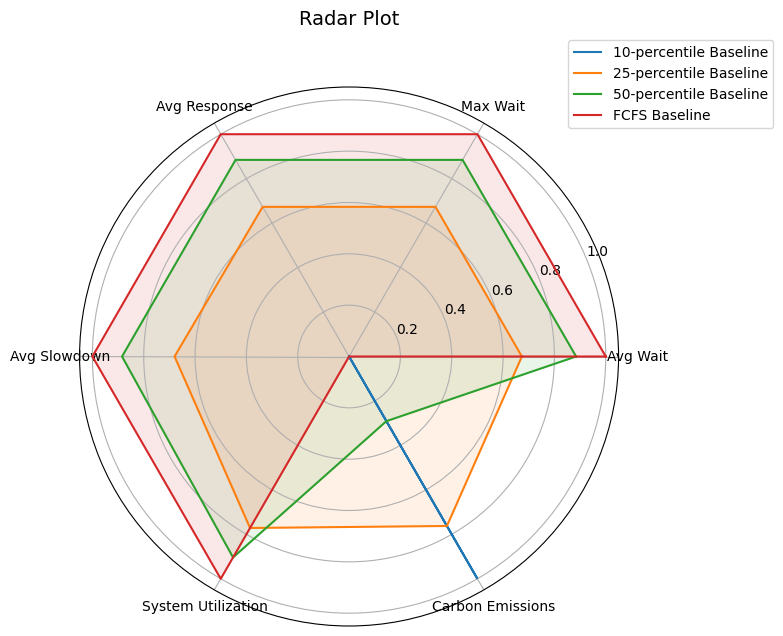

In [4]:
plot_scheduler_radar(data)